##  Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/User/Student_Academic_Performance.csv")

print("First 5 Records:\n")
print(df.head())

First 5 Records:

  Department  Gender Parent_Education ESE_Preparation  Study_Hours  \
0        CSE    Male         Graduate            Well          8.5   
1        ECE  Female    Post_Graduate            Well          6.2   
2        CSE    Male         Graduate          Medium          4.0   
3        CSE  Female    Post_Graduate            Well          9.0   
4        ECE    Male         Graduate          Medium          5.5   

   Attendance_Percentage  Internal_Assessment  Lab_Test_Score  \
0                     92                   18              22   
1                     85                   15              20   
2                     70                   10              15   
3                     95                   19              24   
4                     78                   12              18   

   External_POE_Score  
0                  20  
1                  18  
2                  12  
3                  22  
4                  15  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###  Required Columns are Clean

In [ ]:
print("\nMissing values before cleaning:\n")
print(df[["Study_Hours",
       "Internal_Assessment",
       "Lab_Test_Score",
       "External_POE_Score"]].isnull().sum())

# Handling missing values (based on Experiment-3)
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Internal_Assessment"] = df["Internal_Assessment"].fillna(df["Internal_Assessment"].mean())
df["Lab_Test_Score"] = df["Lab_Test_Score"].fillna(df["Lab_Test_Score"].mean())
df["External_POE_Score"] = df["External_POE_Score"].fillna(df["External_POE_Score"].mean())
print("\nMissing values after cleaning:\n")
print(df[["Study_Hours",
       "Internal_Assessment",
       "Lab_Test_Score",
       "External_POE_Score"]].isnull().sum())


Missing values before cleaning:

Study_Hours            0
Internal_Assessment    0
Lab_Test_Score         0
External_POE_Score     0
dtype: int64

Missing values after cleaning:

Study_Hours            0
Internal_Assessment    0
Lab_Test_Score         0
External_POE_Score     0
dtype: int64


### Createing Target Variable avg score / std hours

In [ ]:
df["Average_Score"] = (df["Internal_Assessment"] +
                        df["Lab_Test_Score"] +
                        df["External_POE_Score"]) / 3
print("\nDataset with Average_Score:\n")
print(df[["Study_Hours", "Average_Score"]].head())


Dataset with Average_Score:

   Study_Hours  Average_Score
0          8.5      20.000000
1          6.2      17.666667
2          4.0      12.333333
3          9.0      21.666667
4          5.5      15.000000


###  Selecting Feature and Target

In [ ]:
X = df[["Study_Hours"]]
y = df["Average_Score"]

###  Training  Model

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

### Predictions

In [ ]:
y_pred = model.predict(X)

print("\nPredicted Values (first 5):\n", y_pred[:5])


Predicted Values (first 5):
 [20.86462766 16.30744681 11.94840426 21.85531915 14.92047872]


###  Model Evaluation

In [ ]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("\nMean Absolute Error:", mae)
print("Mean Squared Error:", mse)


Mean Absolute Error: 0.5681205673758859
Mean Squared Error: 0.4809574468085098


###  Visualization


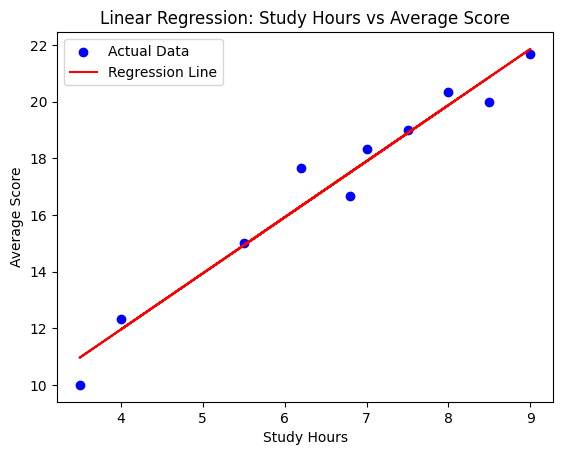

In [ ]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Linear Regression: Study Hours vs Average Score")
plt.legend()

plt.show()

### Predict New Value

---



In [ ]:
new_hours = [[5]]
predicted_score = model.predict(new_hours)
print("\nPredicted Average Score for 5 Study Hours:", predicted_score[0])